# 5.2 案例实战：员工离职预测模型搭建

In [7]:
df = df.replace({'工资': {'低': 0, '中': 1, '高': 2}})
df.head()

,工资,满意度,考核得分,工程数量,月工时,工龄,离职
0,0,3.8,0.53,2,157,3,1
1,1,8.0,0.86,5,262,6,1
2,1,1.1,0.88,7,272,4,1
3,0,7.2,0.87,5,223,5,1
4,0,3.7,0.52,2,159,3,1


In [9]:
df = df.replace({'工资': {'低': 0, '中': 1, '高': 2}})
df.head()

,工资,满意度,考核得分,工程数量,月工时,工龄,离职
0,0,3.8,0.53,2,157,3,1
1,1,8.0,0.86,5,262,6,1
2,1,1.1,0.88,7,272,4,1
3,0,7.2,0.87,5,223,5,1
4,0,3.7,0.52,2,159,3,1


In [11]:
X = df.drop(columns='离职') # 删除离职列
y = df['离职']  # 目标变量

In [13]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=123)

# 逻辑回归模型

In [23]:
#模型训练及搭建
# 模型训练及搭建
from sklearn.linear_model import LogisticRegression
lr_model = LogisticRegression(random_state=123, max_iter=1000)  # 增加迭代次数
lr_model.fit(X_train, y_train)

LogisticRegression(max_iter=1000, random_state=123)

[0 0 0 0 1 0 0 0 0 1 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 1 0
 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 1 0 0 0 0 1 0 1 0 0 0]
    预测值  实际值
0     0    0
1     0    0
2     0    1
3     0    0
4     1    0
5     0    0
6     0    1
7     0    0
8     0    0
9     1    0
10    0    0
11    0    0
12    0    0
13    0    0
14    1    0
15    0    1
16    0    0
17    0    1
18    0    0
19    0    0
逻辑回归准确度: 0.782
[[0.92801446 0.07198554]
 [0.94097101 0.05902899]
 [0.85111012 0.14888988]
 [0.91077839 0.08922161]
 [0.42948807 0.57051193]]
      不离职概率      离职概率
0  0.928014  0.071986
1  0.940971  0.059029
2  0.851110  0.148890
3  0.910778  0.089222
4  0.429488  0.570512
           阈值      假警报率  命中率
0         inf  0.000000  0.0
1    0.862094  0.000433  0.0
2    0.854736  0.000867  0.0
3    0.832985  0.001733  0.0
4    0.782639  0.004766  0.0
..        ...       ...  ...
867  0.027291  0.964038  1.0
868  0.027271  0.9

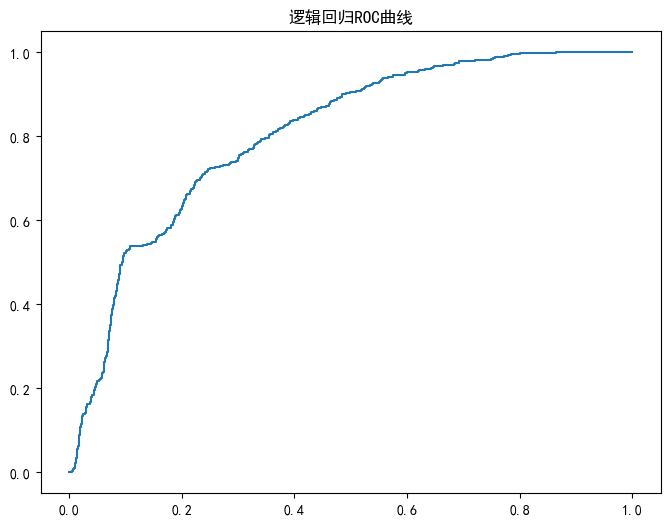

逻辑回归AUC值: 0.8045319872571904


In [27]:
#模型预测及评估
# 2.1 直接预测是否离职
lr_y_pred = lr_model.predict(X_test)
print(lr_y_pred[0:100])

# 通过构造DataFrame进行对比
lr_a = pd.DataFrame()
lr_a['预测值'] = list(lr_y_pred)
lr_a['实际值'] = list(y_test)
print(lr_a.head(20))

# 查看整体预测准确度
from sklearn.metrics import accuracy_score
lr_score = accuracy_score(lr_y_pred, y_test)
print("逻辑回归准确度:", lr_score)

# 2.2 预测不离职及离职概率
lr_y_pred_proba = lr_model.predict_proba(X_test)
print(lr_y_pred_proba[0:5])

lr_b = pd.DataFrame(lr_y_pred_proba, columns=['不离职概率', '离职概率'])
print(lr_b.head())

# 2.3 模型预测效果评估
from sklearn.metrics import roc_curve, roc_auc_score
lr_fpr, lr_tpr, lr_thres = roc_curve(y_test, lr_y_pred_proba[:,1])

# 查看不同阈值下的假警报率和命中率
lr_thres_df = pd.DataFrame()
lr_thres_df['阈值'] = list(lr_thres)
lr_thres_df['假警报率'] = list(lr_fpr)
lr_thres_df['命中率'] = list(lr_tpr)
print(lr_thres_df)

# 绘制ROC曲线
import matplotlib.pyplot as plt
plt.rcParams['font.sans-serif'] = ['SimHei']  # 用来正常显示中文标签
plt.rcParams['axes.unicode_minus'] = False    # 用来正常显示负号

import matplotlib.pyplot as plt
plt.figure(figsize=(8, 6))
plt.plot(lr_fpr, lr_tpr)
plt.title('逻辑回归ROC曲线')
plt.show()

# 计算AUC值
lr_auc = roc_auc_score(y_test, lr_y_pred_proba[:,1])
print("逻辑回归AUC值:", lr_auc)

# 随机森林模型


In [30]:
#模型训练及搭建
from sklearn.ensemble import RandomForestClassifier
rf_model = RandomForestClassifier(n_estimators=100, random_state=123)
rf_model.fit(X_train, y_train)

RandomForestClassifier(random_state=123)

[0 0 1 0 0 0 1 0 0 0 0 0 0 0 0 1 0 1 0 0 0 0 0 0 0 0 0 1 1 0 1 0 1 0 0 1 0
 1 0 0 0 0 0 1 0 0 0 0 0 0 0 1 0 0 1 0 0 1 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0
 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 1 1 1 0 0 0]
    预测值  实际值
0     0    0
1     0    0
2     1    1
3     0    0
4     0    0
5     0    0
6     1    1
7     0    0
8     0    0
9     0    0
10    0    0
11    0    0
12    0    0
13    0    0
14    0    0
15    1    1
16    0    0
17    1    1
18    0    0
19    0    0
随机森林准确度: 0.994
[[0.81 0.19]
 [1.   0.  ]
 [0.   1.  ]
 [1.   0.  ]
 [0.98 0.02]]
   不离职概率  离职概率
0   0.81  0.19
1   1.00  0.00
2   0.00  1.00
3   1.00  0.00
4   0.98  0.02
      阈值      假警报率       命中率
0    inf  0.000000  0.000000
1   1.00  0.000433  0.781792
2   0.99  0.000433  0.841040
3   0.98  0.000433  0.872832
4   0.97  0.000433  0.890173
5   0.96  0.000433  0.898844
6   0.95  0.000433  0.906069
7   0.94  0.000433  0.917630
8   0.92  0.000433  0.920520
9   0.91  0.000433  0.930636
10  0.90  0.000433  0.933526
11  

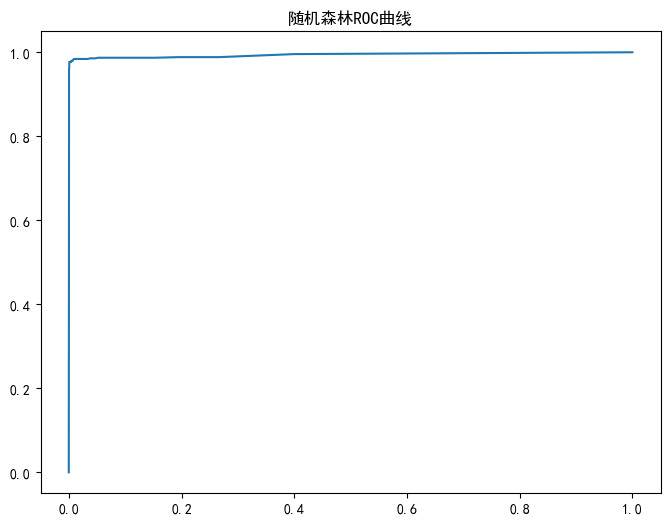

随机森林AUC值: 0.9938755998236842
随机森林特征重要性:
   特征名称     特征重要性
1   满意度  0.351536
5    工龄  0.185623
3  工程数量  0.181493
4   月工时  0.146782
2  考核得分  0.125931
0    工资  0.008635


In [32]:
#模型预测及评估
# 2.1 直接预测是否离职
rf_y_pred = rf_model.predict(X_test)
print(rf_y_pred[0:100])

# 通过构造DataFrame进行对比
rf_a = pd.DataFrame()
rf_a['预测值'] = list(rf_y_pred)
rf_a['实际值'] = list(y_test)
print(rf_a.head(20))

# 查看整体预测准确度
rf_score = accuracy_score(rf_y_pred, y_test)
print("随机森林准确度:", rf_score)

# 2.2 预测不离职及离职概率
rf_y_pred_proba = rf_model.predict_proba(X_test)
print(rf_y_pred_proba[0:5])

rf_b = pd.DataFrame(rf_y_pred_proba, columns=['不离职概率', '离职概率'])
print(rf_b.head())

# 2.3 模型预测效果评估
rf_fpr, rf_tpr, rf_thres = roc_curve(y_test, rf_y_pred_proba[:,1])

# 查看不同阈值下的假警报率和命中率
rf_thres_df = pd.DataFrame()
rf_thres_df['阈值'] = list(rf_thres)
rf_thres_df['假警报率'] = list(rf_fpr)
rf_thres_df['命中率'] = list(rf_tpr)
print(rf_thres_df)

# 绘制ROC曲线
plt.figure(figsize=(8, 6))
plt.plot(rf_fpr, rf_tpr)
plt.title('随机森林ROC曲线')
plt.show()

# 计算AUC值
rf_auc = roc_auc_score(y_test, rf_y_pred_proba[:,1])
print("随机森林AUC值:", rf_auc)

# 2.4 特征重要性评估
rf_features = X.columns
rf_importances = rf_model.feature_importances_

rf_importances_df = pd.DataFrame()
rf_importances_df['特征名称'] = rf_features
rf_importances_df['特征重要性'] = rf_importances
rf_importances_df = rf_importances_df.sort_values('特征重要性', ascending=False)
print("随机森林特征重要性:")
print(rf_importances_df)

# 支持向量机模型

In [35]:
#模型训练及搭建
from sklearn.svm import SVC
svm_model = SVC(probability=True, random_state=123)
svm_model.fit(X_train, y_train)

SVC(probability=True, random_state=123)

[0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 1 0 0 0 0 0]
    预测值  实际值
0     0    0
1     0    0
2     0    1
3     0    0
4     0    0
5     0    0
6     0    1
7     0    0
8     0    0
9     0    0
10    0    0
11    0    0
12    0    0
13    0    0
14    1    0
15    0    1
16    0    0
17    0    1
18    0    0
19    0    0
支持向量机准确度: 0.7996666666666666
[[0.8767446  0.1232554 ]
 [0.92841124 0.07158876]
 [0.90928658 0.09071342]
 [0.70520076 0.29479924]
 [0.69968161 0.30031839]]
      不离职概率      离职概率
0  0.876745  0.123255
1  0.928411  0.071589
2  0.909287  0.090713
3  0.705201  0.294799
4  0.699682  0.300318
           阈值      假警报率       命中率
0         inf  0.000000  0.000000
1    0.999996  0.000000  0.001445
2    0.999990  0.000000  0.014451
3    0.999990  0.000000  0.017341
4    0.999989  0.000000  0.018786
..        ...       ...       ..

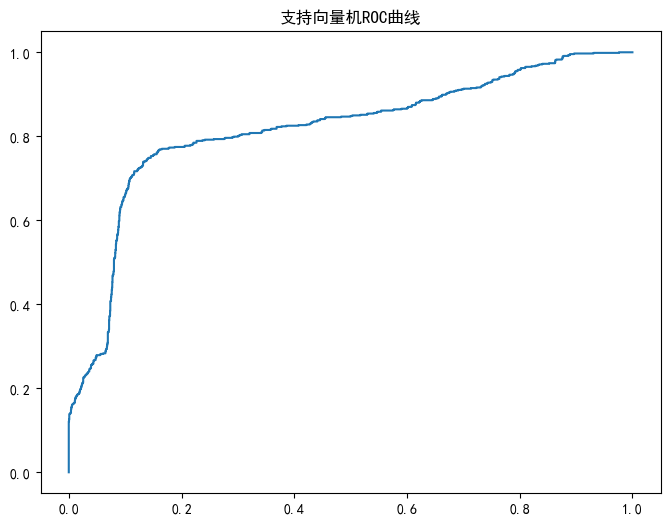

支持向量机AUC值: 0.8164749276204405


In [37]:
#模型预测及评估
# 2.1 直接预测是否离职
svm_y_pred = svm_model.predict(X_test)
print(svm_y_pred[0:100])

# 通过构造DataFrame进行对比
svm_a = pd.DataFrame()
svm_a['预测值'] = list(svm_y_pred)
svm_a['实际值'] = list(y_test)
print(svm_a.head(20))

# 查看整体预测准确度
svm_score = accuracy_score(svm_y_pred, y_test)
print("支持向量机准确度:", svm_score)

# 2.2 预测不离职及离职概率
svm_y_pred_proba = svm_model.predict_proba(X_test)
print(svm_y_pred_proba[0:5])

svm_b = pd.DataFrame(svm_y_pred_proba, columns=['不离职概率', '离职概率'])
print(svm_b.head())

# 2.3 模型预测效果评估
svm_fpr, svm_tpr, svm_thres = roc_curve(y_test, svm_y_pred_proba[:,1])

# 查看不同阈值下的假警报率和命中率
svm_thres_df = pd.DataFrame()
svm_thres_df['阈值'] = list(svm_thres)
svm_thres_df['假警报率'] = list(svm_fpr)
svm_thres_df['命中率'] = list(svm_tpr)
print(svm_thres_df)

# 绘制ROC曲线
plt.figure(figsize=(8, 6))
plt.plot(svm_fpr, svm_tpr)
plt.title('支持向量机ROC曲线')
plt.show()

# 计算AUC值
svm_auc = roc_auc_score(y_test, svm_y_pred_proba[:,1])
print("支持向量机AUC值:", svm_auc)